<a href="https://colab.research.google.com/github/MachineLearning30110/MachineLearning-Models/blob/main/LinearRegressionMetrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pickle
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
drive_path = '/content/drive/MyDrive/Colab Notebooks/'
model_path = drive_path + 'LinearRegression_CaliforniaHousing.pkl'

with open(model_path, 'rb') as f:
    model = pickle.load(f)

In [5]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [7]:
X = df.drop("target", axis=1)
y = df["target"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# Metrics
train_mse = mean_squared_error(y_train, train_preds)
test_mse = mean_squared_error(y_test, test_preds)

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train MSE: 0.5205320252001898
Test MSE: 0.5590019245025631
Train R2: 0.6090110220005638
Test R2: 0.5808353312067694


In [10]:
import matplotlib.pyplot as plt

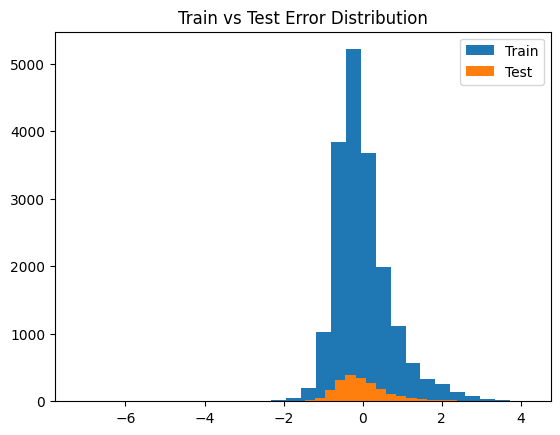

In [20]:
train_residuals = y_train - train_preds
test_residuals = y_test - test_preds

plt.hist(train_residuals, bins=30, label="Train")
plt.hist(test_residuals, bins=30, label="Test")

plt.title("Train vs Test Error Distribution")
plt.legend()

plt.show()

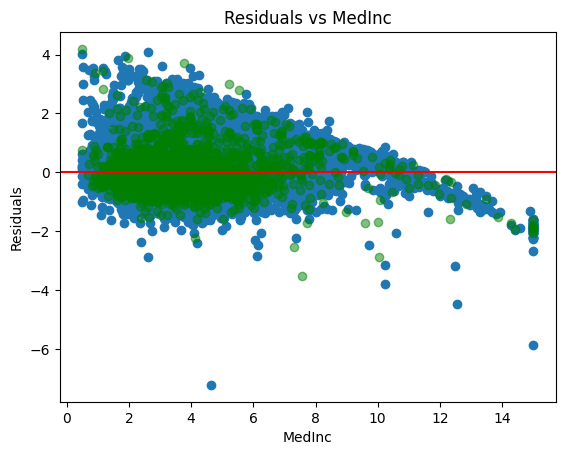

In [18]:
feature = "MedInc"

plt.scatter(X_train[feature], train_residuals)
plt.scatter(X_test[feature], test_residuals,c="green",alpha=0.5)
plt.xlabel(feature)
plt.ylabel("Residuals")
plt.title(f"Residuals vs {feature}")

plt.axhline(0,color="red")

plt.show()